# 52 Random Forest 3 — RF, Extra Trees, RF Regularizado y Quantile RF

Cuatro variantes de modelos basados en árboles aleatorios sobre `sale` y `rent` prediciendo `log_precio`.

- **Random Forest** — modelo base de referencia
- **Extra Trees** — árboles con splits totalmente aleatorios (menos varianza, más sesgo)
- **RF Regularizado** — RF con `ccp_alpha` (poda por complejidad) para reducir sobreajuste
- **Quantile RF** — permite predicción de intervalos de confianza (mediana = predicción puntual)

Para el Quantile RF se usa el paquete `quantile-forest` (`pip install quantile-forest`).

- Municipios con < 10 observaciones → `municipio_otro`
- Split 80/20 train-test, CV de 5 folds
- Modelo base primero, luego GridSearchCV

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV

try:
    from quantile_forest import RandomForestQuantileRegressor
    QRF_AVAILABLE = True
except ImportError:
    print("AVISO: quantile-forest no está instalado. Instala con: pip install quantile-forest")
    QRF_AVAILABLE = False

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5
MIN_OBS_MUNICIPIO = 10

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

print("Datasets:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")
print(f"Quantile RF disponible: {QRF_AVAILABLE}")

AVISO: quantile-forest no está instalado. Instala con: pip install quantile-forest
Datasets:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv
Quantile RF disponible: False


In [2]:
# ── Features ──────────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "latitud",
    "longitud",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
]

MUNICIPIO_FEATURES = [
    "municipio_Ampuero",
    "municipio_Barcena de Cicero",
    "municipio_Camargo",
    "municipio_Cartes",
    "municipio_Castro-Urdiales",
    "municipio_Colindres",
    "municipio_Cudon",
    "municipio_El Astillero",
    "municipio_Entrambasaguas",
    "municipio_Gallarta",
    "municipio_Getxo",
    "municipio_Guarnizo",
    "municipio_Guriezo",
    "municipio_Laredo",
    "municipio_Liendo",
    "municipio_Limpias",
    "municipio_Marina de Cudeyo",
    "municipio_Miengo",
    "municipio_Noja",
    "municipio_Piélagos",
    "municipio_Polanco",
    "municipio_Ramales de la Victoria",
    "municipio_Reocin",
    "municipio_Ribamontan al Mar",
    "municipio_Santa Cruz de Bezana",
    "municipio_Santa Maria de Cayon",
    "municipio_Santander",
    "municipio_Santillana del Mar",
    "municipio_Santoña",
    "municipio_Santurtzi",
    "municipio_Sobremazas",
    "municipio_Solares",
    "municipio_Suances",
    "municipio_Torrelavega",
    "municipio_Villaescusa",
    "municipio_Villapresente",
    "municipio_Viveda",
    "municipio_Voto",
]

# ── Grids de hiperparámetros ──────────────────────────────────────────────────

# Random Forest estándar
PARAM_GRID_RF = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 20, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features":    ["sqrt", 0.4, 0.6],
}

# Extra Trees
PARAM_GRID_ET = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 20, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features":    ["sqrt", 0.4, 0.6],
}

# RF Regularizado (poda por complejidad con ccp_alpha)
PARAM_GRID_RRF = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 15, 20],
    "min_samples_leaf": [5, 10, 20],
    "max_features":    ["sqrt", 0.4],
    "ccp_alpha":       [0.0001, 0.001, 0.01],
}

# Quantile RF (predicción puntual = mediana, q=0.5)
PARAM_GRID_QRF = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 20, None],
    "min_samples_leaf": [5, 10, 20],
    "max_features":    ["sqrt", 0.4, 0.6],
}

In [3]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(mse,  5)],
        "RMSE": [round(rmse, 5)],
        "MAE":  [round(mae,  5)],
        "R2":   [round(r2,   5)],
        "MAPE": [round(mape, 5)],
    })


def collapse_rare_municipios(df: pd.DataFrame, muni_cols: list, min_obs: int) -> tuple:
    """
    Identifica columnas municipio_* con < min_obs observaciones (suma binaria)
    y las colapsa en 'municipio_otro'.
    """
    present = [c for c in muni_cols if c in df.columns]
    absent  = [c for c in muni_cols if c not in df.columns]
    if absent:
        print(f"  Municipios no presentes en el dataset: {absent}")

    counts = df[present].sum()
    rare   = counts[counts < min_obs].index.tolist()
    common = counts[counts >= min_obs].index.tolist()

    print(f"  Municipios con >= {min_obs} obs: {len(common)}")
    print(f"  Municipios con <  {min_obs} obs (-> municipio_otro): {len(rare)}")
    if rare:
        print(f"    {rare}")

    df = df.copy()
    if rare:
        df["municipio_otro"] = df[rare].any(axis=1).astype(int)
        df = df.drop(columns=rare)
        final_muni_cols = common + ["municipio_otro"]
    else:
        final_muni_cols = common

    return df, final_muni_cols


def prepare_X(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    cols = [c for c in feature_cols if c in df.columns]
    X = df[cols].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real - predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances: np.ndarray, feature_names: list, title: str, top_n: int = 15):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


def plot_prediction_intervals(y_test, pred_low, pred_median, pred_high, title_prefix: str):
    """Gráfico de intervalos de predicción para Quantile RF."""
    idx     = np.argsort(y_test)
    y_sort  = np.array(y_test)[idx]
    lo_sort = pred_low[idx]
    me_sort = pred_median[idx]
    hi_sort = pred_high[idx]

    coverage = np.mean((y_sort >= lo_sort) & (y_sort <= hi_sort))
    interval_width = np.mean(hi_sort - lo_sort)

    fig, ax = plt.subplots(figsize=(12, 5))
    x_plot = np.arange(len(y_sort))
    ax.fill_between(x_plot, lo_sort, hi_sort, alpha=0.25, color="steelblue", label="IC 80% (q10-q90)")
    ax.plot(x_plot, me_sort, color="steelblue", linewidth=1, label="Mediana (q50)")
    ax.scatter(x_plot, y_sort, s=5, color="red", alpha=0.4, label="Real")
    ax.set_title(f"{title_prefix} | Intervalos de prediccion (test, ordenado por valor real)\n"
                 f"Cobertura IC 80%: {coverage:.1%} | Amplitud media: {interval_width:.4f}")
    ax.set_xlabel("Observacion (ordenada)")
    ax.set_ylabel("log_precio")
    ax.legend()
    plt.tight_layout()
    plt.show()


def run_base_model(model, X_train, X_test, y_train, y_test, model_name: str):
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    m_train = get_metrics(y_train, model.predict(X_train))
    m_test  = get_metrics(y_test,  model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_grid_search(estimator, param_grid, X_train, X_test, y_train, y_test, model_name: str):
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse    = float(-gs.best_score_)
    best_model = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    m_train = get_metrics(y_train, best_model.predict(X_train))
    m_test  = get_metrics(y_test,  best_model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


def run_qrf_base(model, X_train, X_test, y_train, y_test, model_name: str):
    """Entrena Quantile RF base. Evalúa con mediana (q=0.5)."""
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train, quantiles=0.5)
    pred_test  = model.predict(X_test,  quantiles=0.5)
    m_train = get_metrics(y_train, pred_train)
    m_test  = get_metrics(y_test,  pred_test)
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_qrf_grid_search(param_grid, X_train, X_test, y_train, y_test, model_name: str):
    """GridSearchCV para Quantile RF usando mediana como prediccion puntual."""
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")

    # GridSearchCV con QRF: predict() por defecto devuelve mediana
    gs = GridSearchCV(
        estimator=RandomForestQuantileRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse    = float(-gs.best_score_)
    best_model = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    pred_train = best_model.predict(X_train, quantiles=0.5)
    pred_test  = best_model.predict(X_test,  quantiles=0.5)
    m_train = get_metrics(y_train, pred_train)
    m_test  = get_metrics(y_test,  pred_test)
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


print("Funciones cargadas.")

Funciones cargadas.



DATASET: SALE
Filas cargadas: 588

Agrupando municipios con < 10 observaciones:
  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (-> municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
Features finales: 28 | Filas: 588
Train: 470 | Test: 118

------------------------------------------------------------
RANDOM FOREST
--------------------------------------------

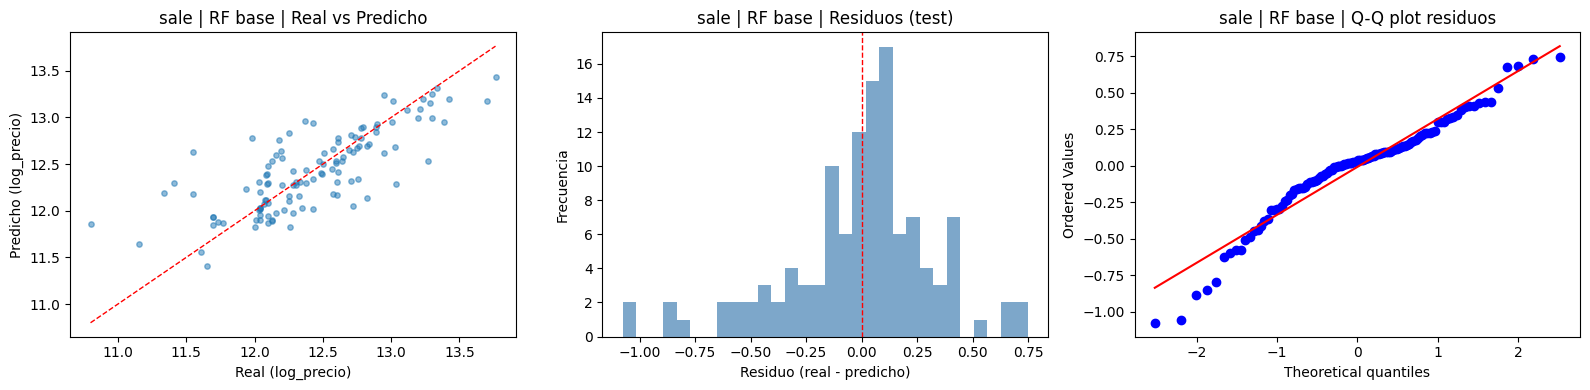

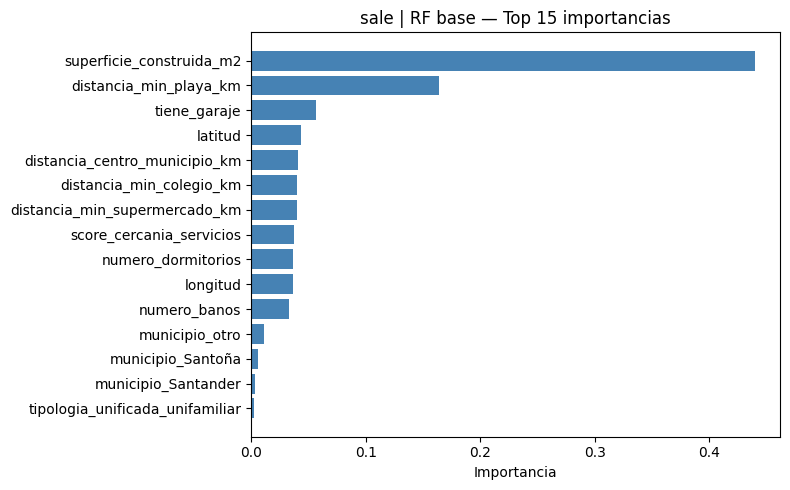


--- Random Forest | GridSearch (54 combinaciones, CV=5) ---


/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

  Mejores params: {'max_depth': None, 'max_features': 0.4, 'min_samples_leaf': 1, 'n_estimators': 400}
  CV RMSE (mejor): 0.35556
split     MSE    RMSE     MAE      R2    MAPE
train 0.01544 0.12428 0.08635 0.95273 0.00704
   CV     NaN 0.35556     NaN     NaN     NaN
 test 0.09613 0.31005 0.21668 0.64695 0.01766
  Sobreajuste -> ratio RMSE test/train: 2.4948 | delta R2: 0.3058


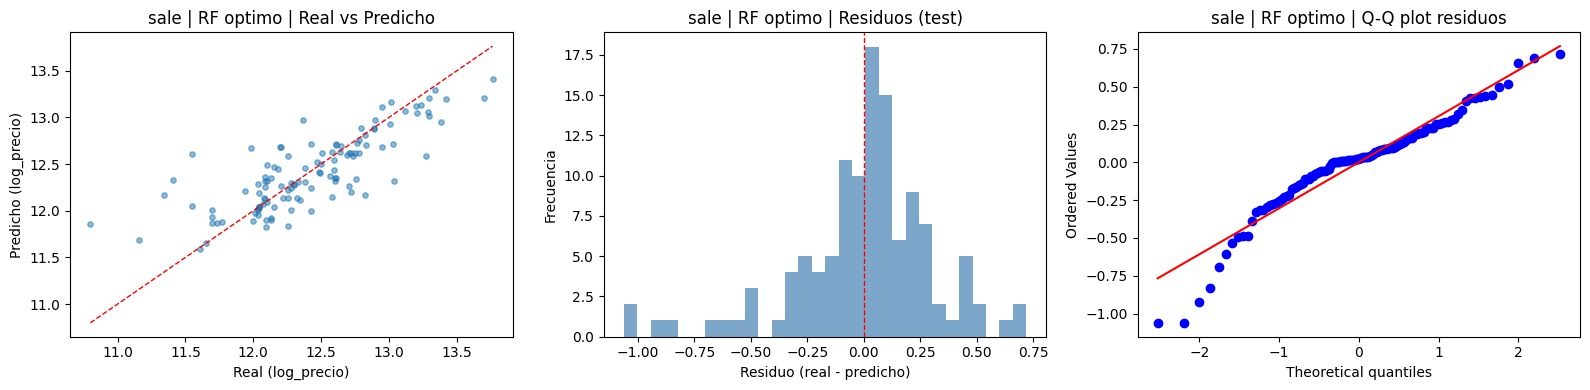

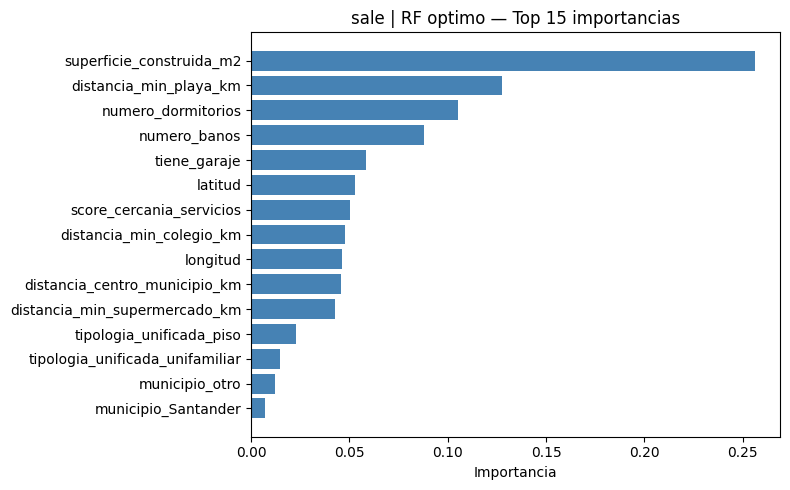


------------------------------------------------------------
EXTRA TREES
------------------------------------------------------------

--- Extra Trees | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00002 0.00456 0.00086 0.99994 0.00007
 test 0.08095 0.28452 0.20339 0.70269 0.01659
  Sobreajuste -> ratio RMSE test/train: 62.3947 | delta R2: 0.2973


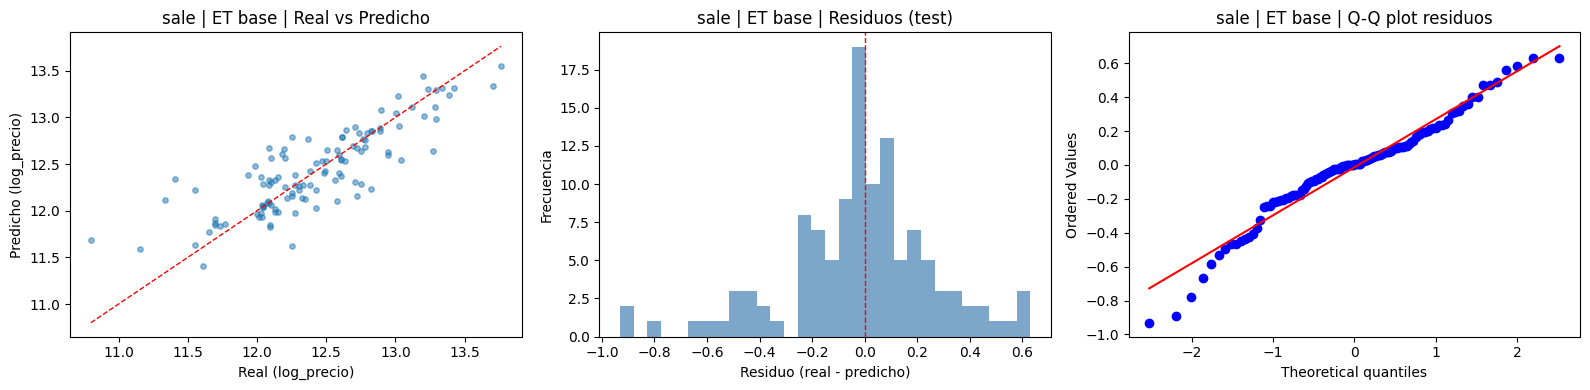

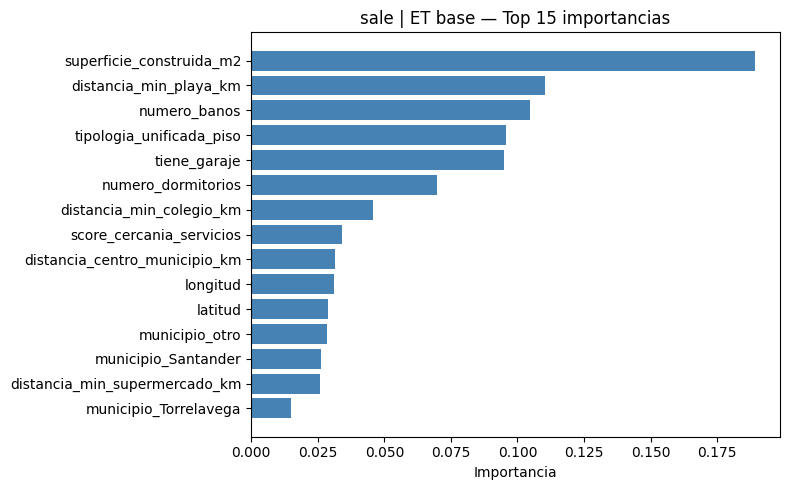


--- Extra Trees | GridSearch (54 combinaciones, CV=5) ---


/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

  Mejores params: {'max_depth': None, 'max_features': 0.4, 'min_samples_leaf': 1, 'n_estimators': 200}
  CV RMSE (mejor): 0.33117
split     MSE    RMSE     MAE      R2    MAPE
train 0.00002 0.00456 0.00086 0.99994 0.00007
   CV     NaN 0.33117     NaN     NaN     NaN
 test 0.08057 0.28385 0.20308 0.70409 0.01656
  Sobreajuste -> ratio RMSE test/train: 62.2478 | delta R2: 0.2959


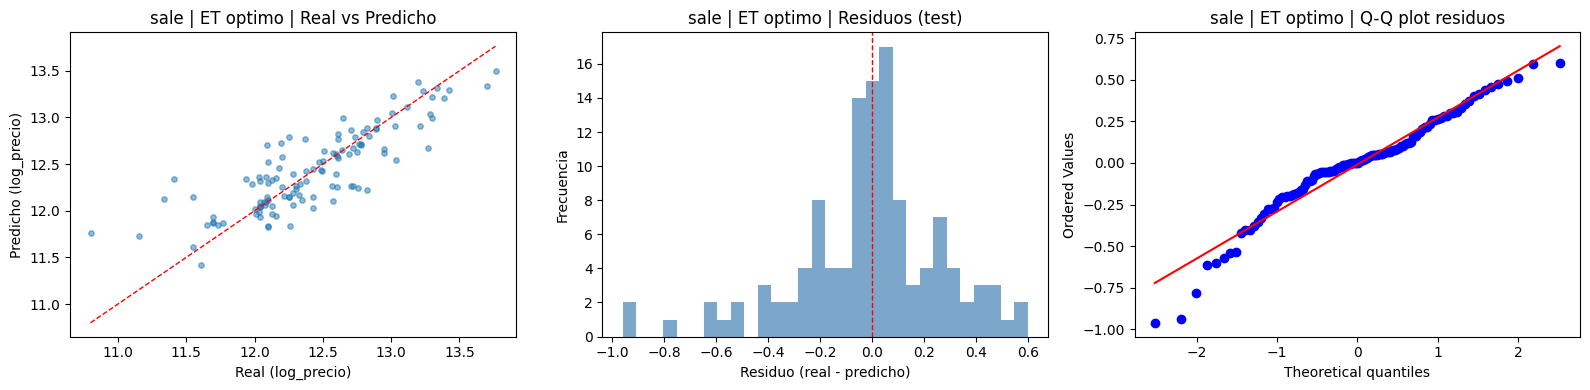

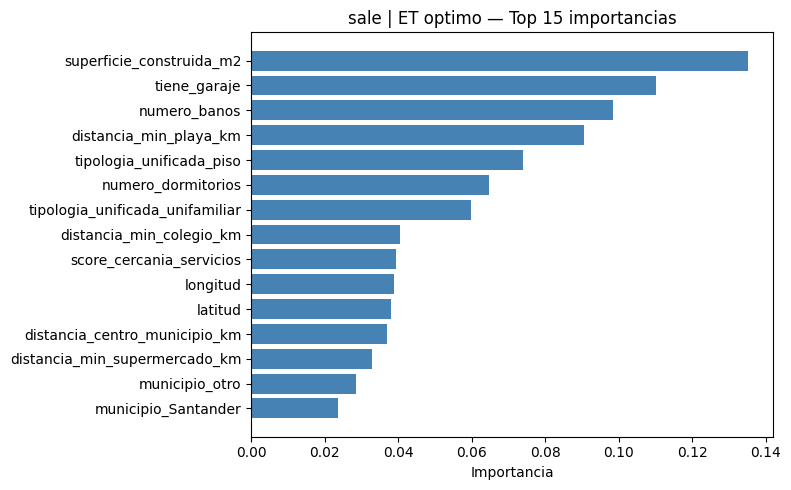


------------------------------------------------------------
RANDOM FOREST REGULARIZADO (ccp_alpha)
------------------------------------------------------------
  ccp_alpha: poda por complejidad de costo. Mayor valor = arboles mas simples.

--- RF Regularizado | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.06341 0.25180 0.17968 0.80592 0.01464
 test 0.10968 0.33119 0.23812 0.59715 0.01936
  Sobreajuste -> ratio RMSE test/train: 1.3153 | delta R2: 0.2088


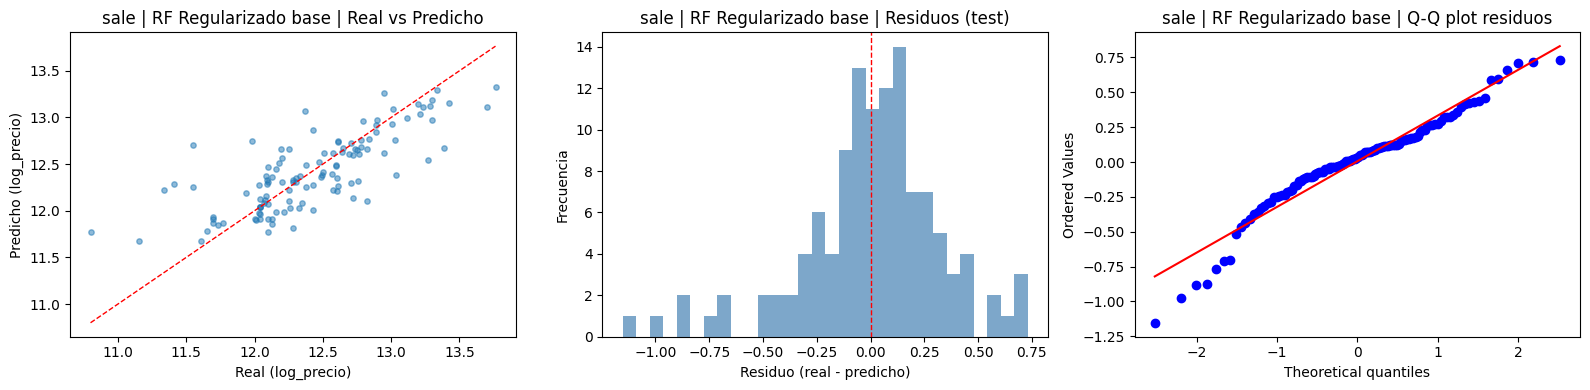

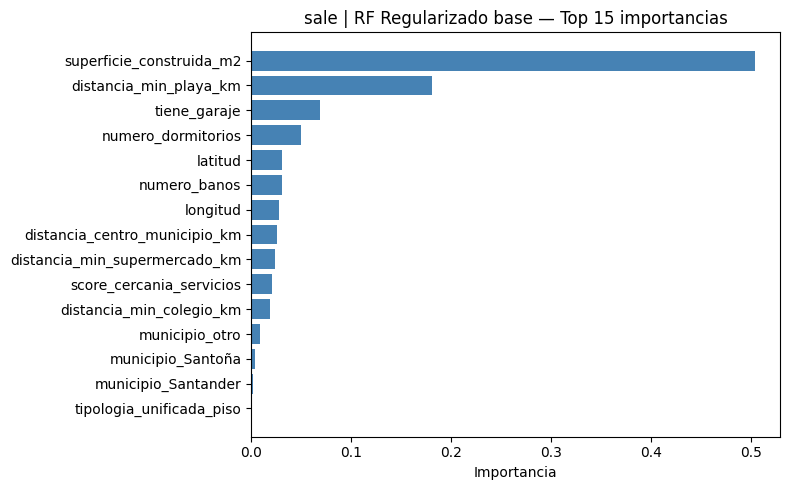


--- RF Regularizado | GridSearch (108 combinaciones, CV=5) ---
  Mejores params: {'ccp_alpha': 0.0001, 'max_depth': 20, 'max_features': 0.4, 'min_samples_leaf': 5, 'n_estimators': 200}
  CV RMSE (mejor): 0.36125
split     MSE    RMSE     MAE      R2    MAPE
train 0.06356 0.25211 0.17735 0.80545 0.01447
   CV     NaN 0.36125     NaN     NaN     NaN
 test 0.10152 0.31863 0.22749 0.62713 0.01850
  Sobreajuste -> ratio RMSE test/train: 1.2639 | delta R2: 0.1783


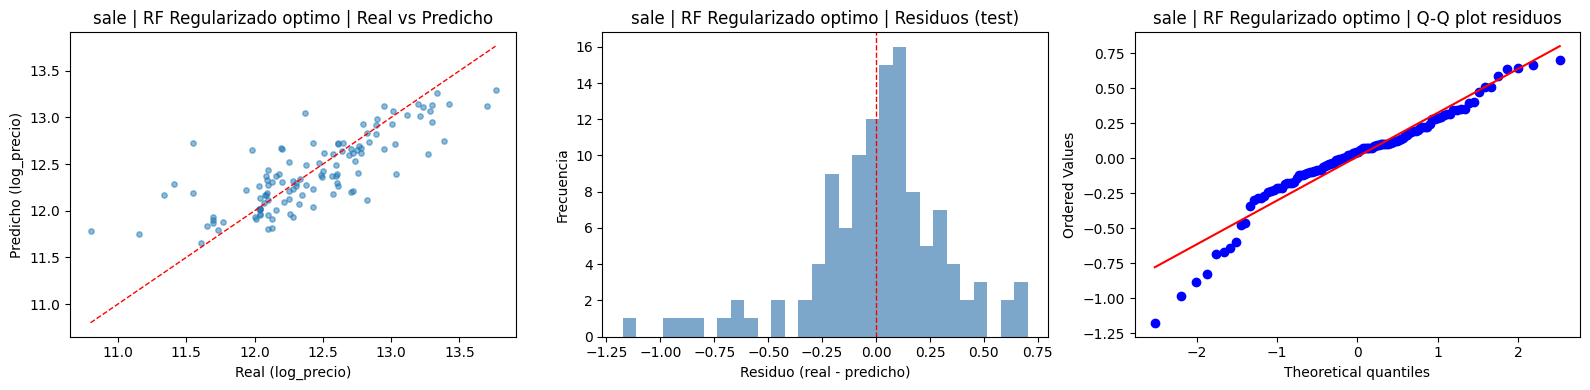

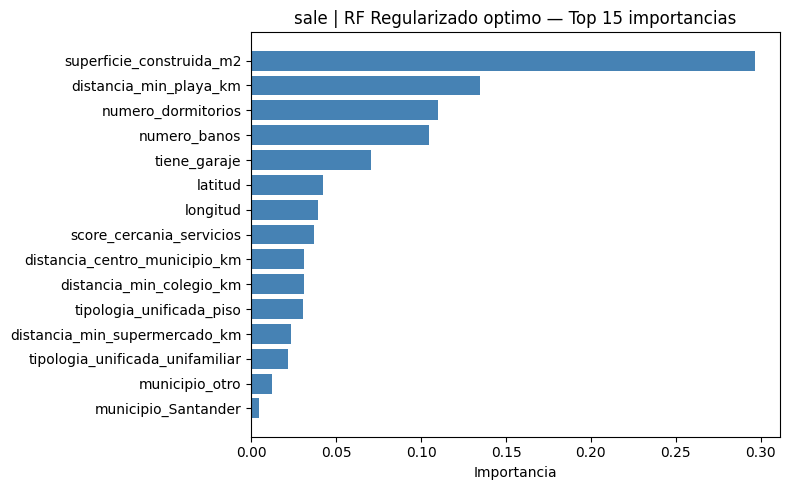


Quantile RF omitido: instala quantile-forest con: pip install quantile-forest

RESUMEN SALE — comparativa modelos
dataset     modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale         RF   base     0.13263    0.33204   0.94616  0.59507      NaN
   sale         RF optimo     0.12428    0.31005   0.95273  0.64695  0.35556
   sale ExtraTrees   base     0.00456    0.28452   0.99994  0.70269      NaN
   sale ExtraTrees optimo     0.00456    0.28385   0.99994  0.70409  0.33117
   sale     RF_Reg   base     0.25180    0.33119   0.80592  0.59715      NaN
   sale     RF_Reg optimo     0.25211    0.31863   0.80545  0.62713  0.36125

DATASET: RENT
Filas cargadas: 477

Agrupando municipios con < 10 observaciones:
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (-> municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getx

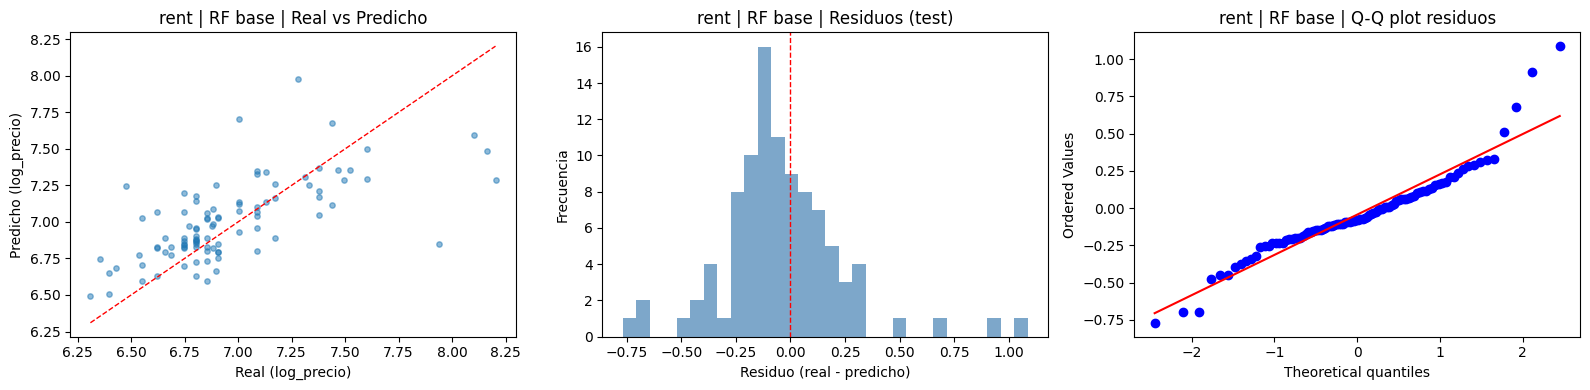

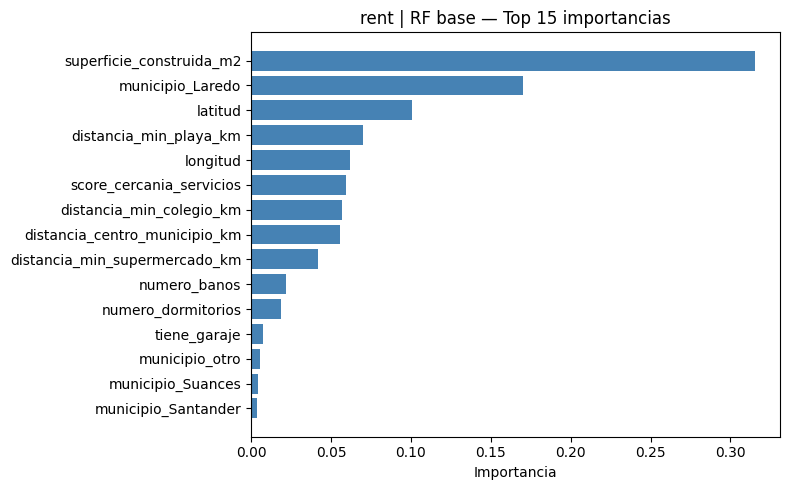


--- Random Forest | GridSearch (54 combinaciones, CV=5) ---
  Mejores params: {'max_depth': 20, 'max_features': 0.4, 'min_samples_leaf': 1, 'n_estimators': 400}
  CV RMSE (mejor): 0.29574
split     MSE    RMSE     MAE      R2    MAPE
train 0.01275 0.11291 0.07835 0.91962 0.01103
   CV     NaN 0.29574     NaN     NaN     NaN
 test 0.07909 0.28123 0.20020 0.41983 0.02837
  Sobreajuste -> ratio RMSE test/train: 2.4907 | delta R2: 0.4998


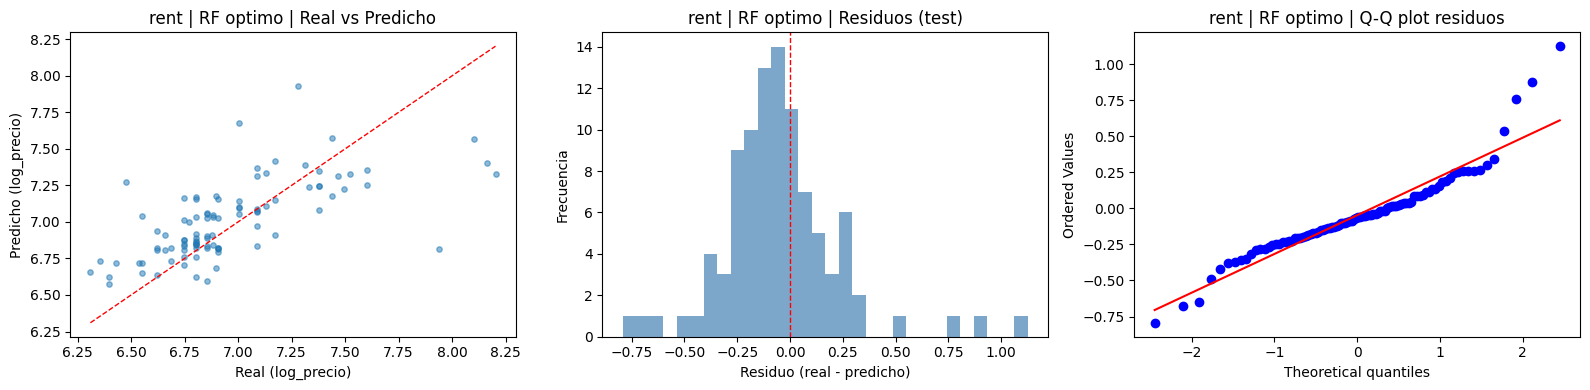

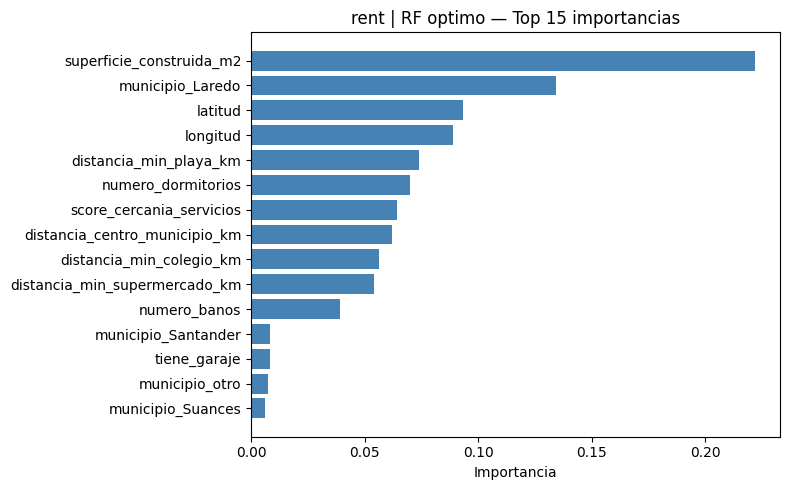


------------------------------------------------------------
EXTRA TREES
------------------------------------------------------------

--- Extra Trees | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00074 0.02719 0.00257 0.99534 0.00034
 test 0.09590 0.30968 0.21282 0.29654 0.03025
  Sobreajuste -> ratio RMSE test/train: 11.3895 | delta R2: 0.6988


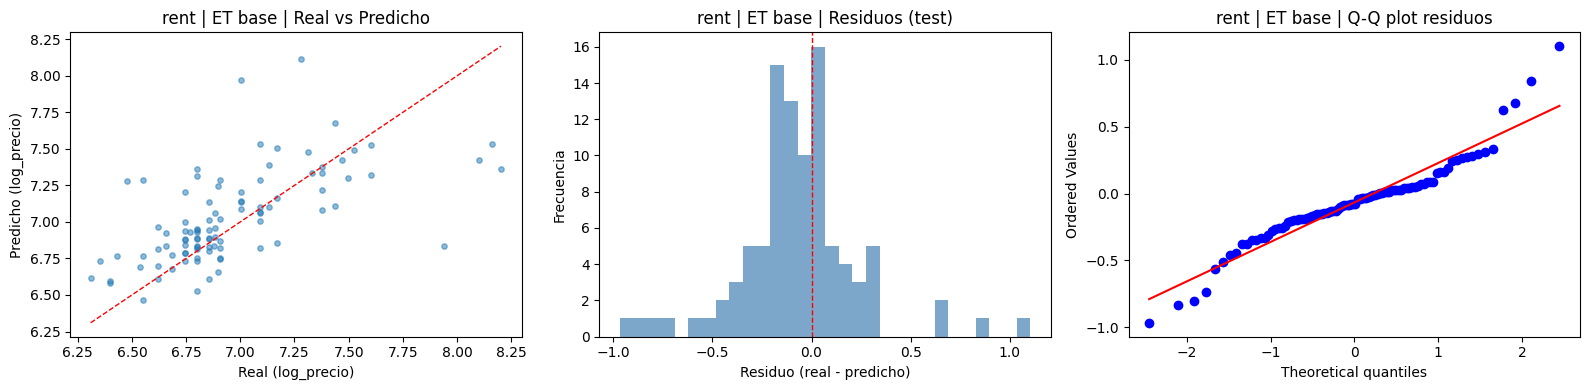

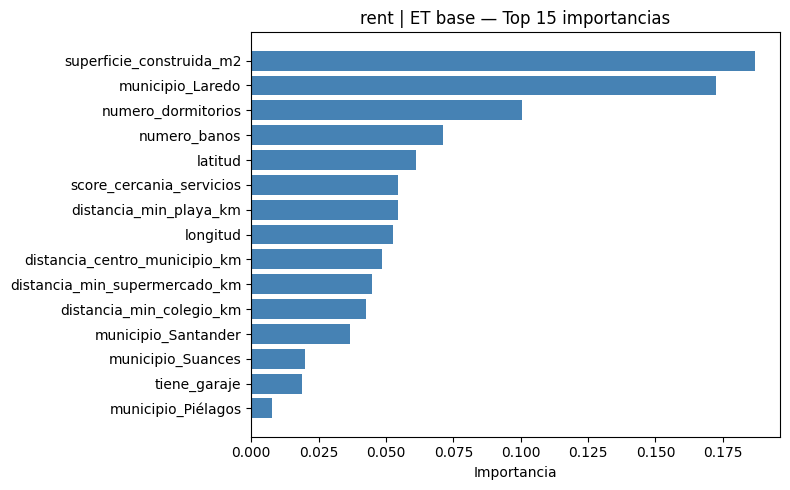


--- Extra Trees | GridSearch (54 combinaciones, CV=5) ---
  Mejores params: {'max_depth': 20, 'max_features': 0.6, 'min_samples_leaf': 5, 'n_estimators': 200}
  CV RMSE (mejor): 0.28871
split     MSE    RMSE     MAE      R2    MAPE
train 0.05312 0.23047 0.15837 0.66509 0.02228
   CV     NaN 0.28871     NaN     NaN     NaN
 test 0.08455 0.29077 0.20239 0.37982 0.02863
  Sobreajuste -> ratio RMSE test/train: 1.2616 | delta R2: 0.2853


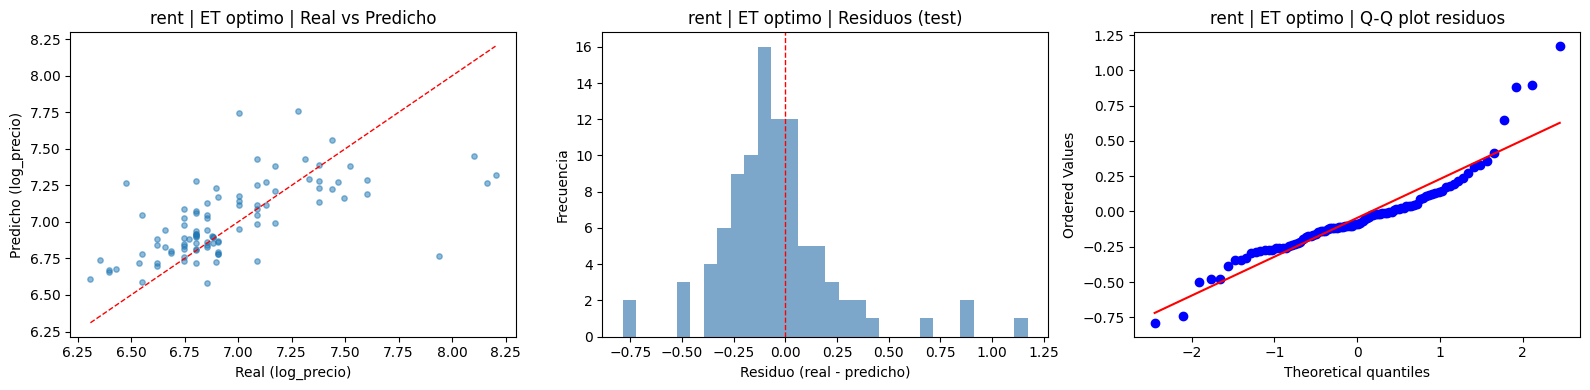

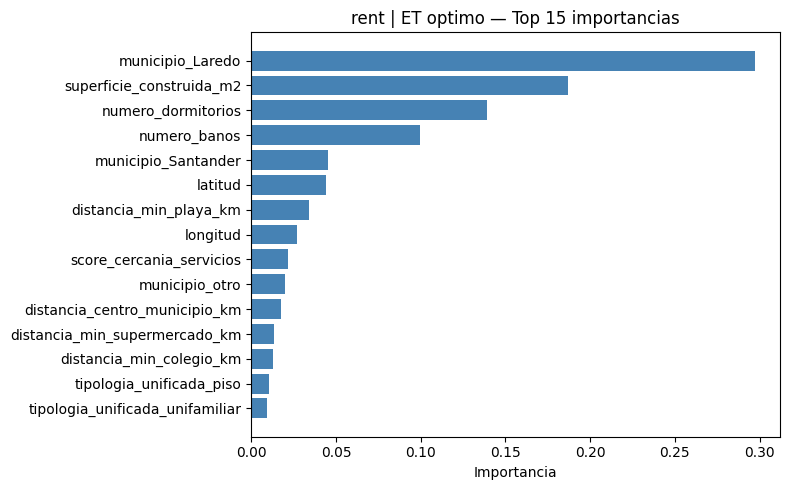


------------------------------------------------------------
RANDOM FOREST REGULARIZADO (ccp_alpha)
------------------------------------------------------------
  ccp_alpha: poda por complejidad de costo. Mayor valor = arboles mas simples.

--- RF Regularizado | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.05143 0.22678 0.16131 0.67573 0.02273
 test 0.07655 0.27667 0.19598 0.43848 0.02769
  Sobreajuste -> ratio RMSE test/train: 1.2200 | delta R2: 0.2373


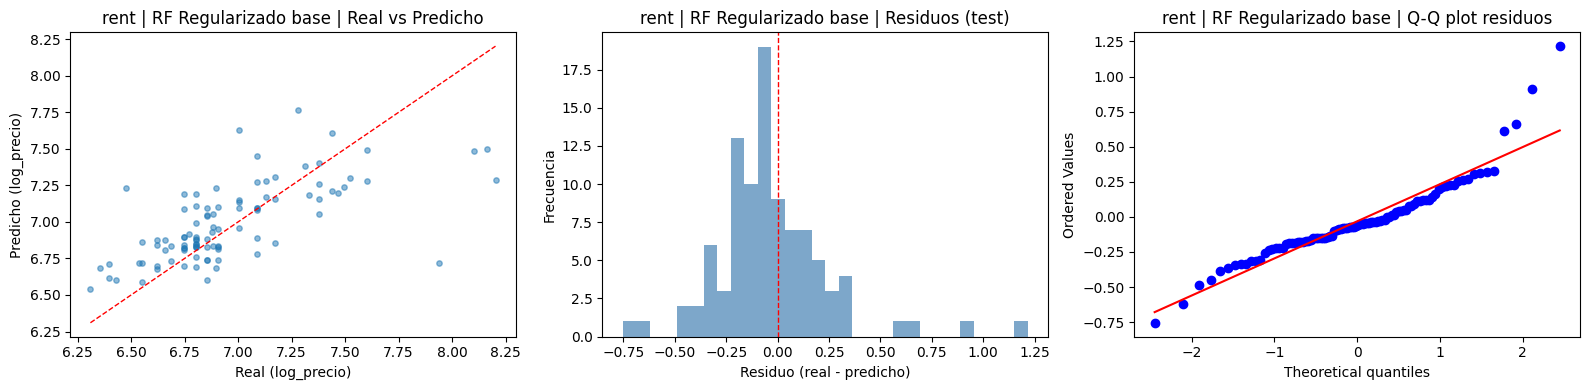

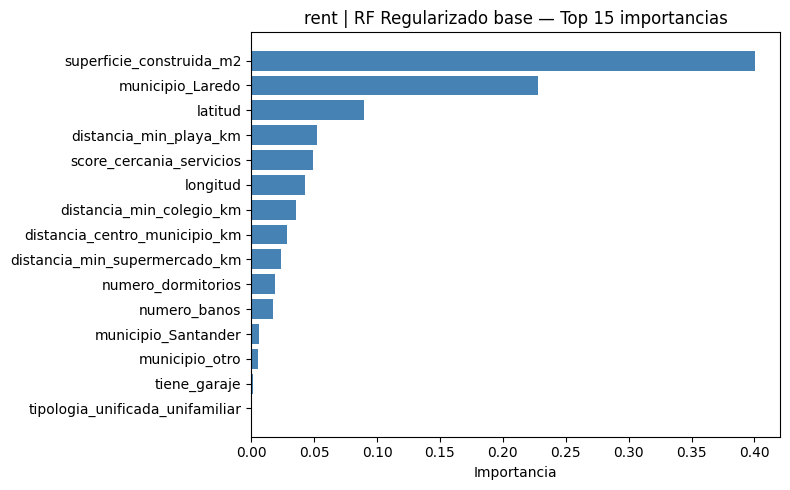


--- RF Regularizado | GridSearch (108 combinaciones, CV=5) ---
  Mejores params: {'ccp_alpha': 0.0001, 'max_depth': 10, 'max_features': 0.4, 'min_samples_leaf': 5, 'n_estimators': 400}
  CV RMSE (mejor): 0.29579
split     MSE    RMSE     MAE      R2    MAPE
train 0.04982 0.22321 0.15461 0.68587 0.02174
   CV     NaN 0.29579     NaN     NaN     NaN
 test 0.07631 0.27625 0.19270 0.44021 0.02726
  Sobreajuste -> ratio RMSE test/train: 1.2376 | delta R2: 0.2457


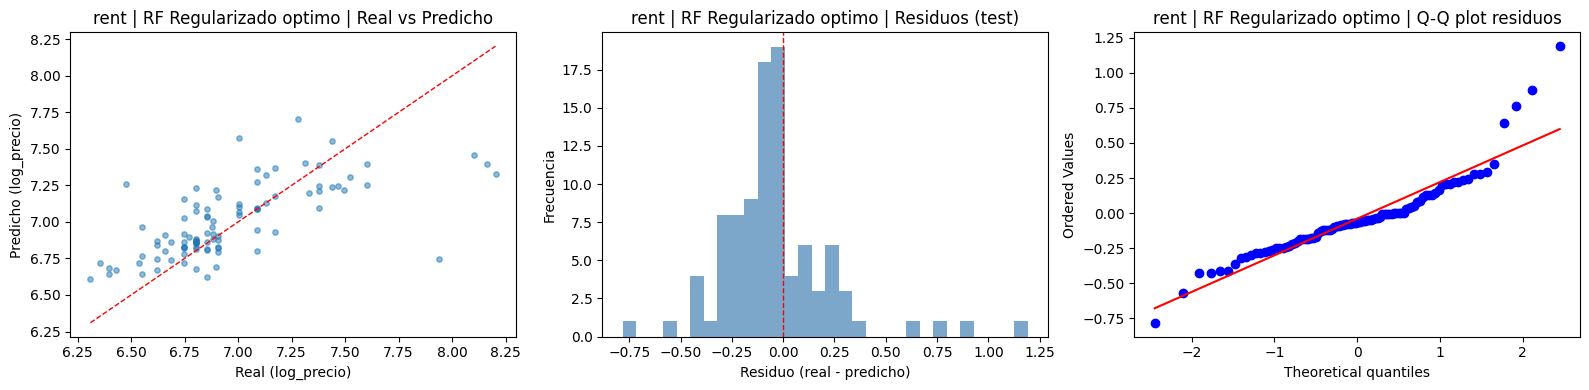

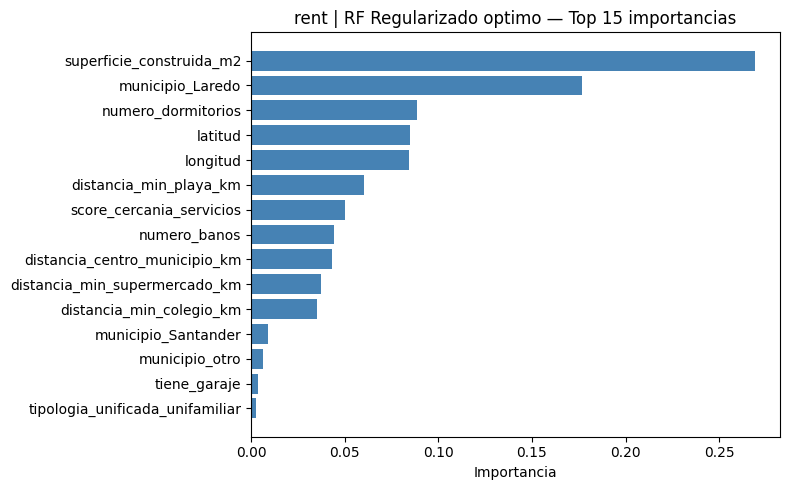


Quantile RF omitido: instala quantile-forest con: pip install quantile-forest

RESUMEN RENT — comparativa modelos
dataset     modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   rent         RF   base     0.11750    0.28079   0.91295  0.42165      NaN
   rent         RF optimo     0.11291    0.28123   0.91962  0.41983  0.29574
   rent ExtraTrees   base     0.02719    0.30968   0.99534  0.29654      NaN
   rent ExtraTrees optimo     0.23047    0.29077   0.66509  0.37982  0.28871
   rent     RF_Reg   base     0.22678    0.27667   0.67573  0.43848      NaN
   rent     RF_Reg optimo     0.22321    0.27625   0.68587  0.44021  0.29579

RESUMEN GLOBAL
dataset     modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale         RF   base     0.13263    0.33204   0.94616  0.59507      NaN
   sale         RF optimo     0.12428    0.31005   0.95273  0.64695  0.35556
   sale ExtraTrees   base     0.00456    0.28452   0.99994  0.70269      NaN
   sale ExtraTrees opt

,dataset,modelo,fase,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE
0,sale,RF,base,0.13263,0.33204,0.94616,0.59507,NaN
1,sale,RF,optimo,0.12428,0.31005,0.95273,0.64695,0.355564
2,sale,ExtraTrees,base,0.00456,0.28452,0.99994,0.70269,NaN
3,sale,ExtraTrees,optimo,0.00456,0.28385,0.99994,0.70409,0.331167
4,sale,RF_Reg,base,0.25180,0.33119,0.80592,0.59715,NaN
5,sale,RF_Reg,optimo,0.25211,0.31863,0.80545,0.62713,0.361250
6,rent,RF,base,0.11750,0.28079,0.91295,0.42165,NaN
7,rent,RF,optimo,0.11291,0.28123,0.91962,0.41983,0.295738
8,rent,ExtraTrees,base,0.02719,0.30968,0.99534,0.29654,NaN
9,rent,ExtraTrees,optimo,0.23047,0.29077,0.66509,0.37982,0.288707


In [4]:
# ── Bucle principal ───────────────────────────────────────────────────────────

all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    # ── Colapsar municipios raros ─────────────────────────────────────────────
    print(f"\nAgrupando municipios con < {MIN_OBS_MUNICIPIO} observaciones:")
    df, final_muni_cols = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)

    # ── Preparar features y split ─────────────────────────────────────────────
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].values

    print(f"Features finales: {X.shape[1]} | Filas: {X.shape[0]}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")
    feature_names = X_train.columns.tolist()

    # ══════════════════════════════════════════════════════════════════════════
    # 1. Random Forest
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "-" * 60)
    print("RANDOM FOREST")
    print("-" * 60)

    rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    rf_base, rf_base_train, rf_base_test = run_base_model(
        rf_base, X_train, X_test, y_train, y_test, "Random Forest"
    )
    plot_diagnostics(y_test, rf_base.predict(X_test), f"{dataset_name} | RF base")
    plot_feature_importance(
        rf_base.feature_importances_, feature_names,
        f"{dataset_name} | RF base — Top 15 importancias"
    )

    rf_opt, rf_gs, rf_opt_train, rf_opt_test, rf_cv_rmse = run_grid_search(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_GRID_RF, X_train, X_test, y_train, y_test, "Random Forest"
    )
    plot_diagnostics(y_test, rf_opt.predict(X_test), f"{dataset_name} | RF optimo")
    plot_feature_importance(
        rf_opt.feature_importances_, feature_names,
        f"{dataset_name} | RF optimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 2. Extra Trees
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "-" * 60)
    print("EXTRA TREES")
    print("-" * 60)

    et_base = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    et_base, et_base_train, et_base_test = run_base_model(
        et_base, X_train, X_test, y_train, y_test, "Extra Trees"
    )
    plot_diagnostics(y_test, et_base.predict(X_test), f"{dataset_name} | ET base")
    plot_feature_importance(
        et_base.feature_importances_, feature_names,
        f"{dataset_name} | ET base — Top 15 importancias"
    )

    et_opt, et_gs, et_opt_train, et_opt_test, et_cv_rmse = run_grid_search(
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_GRID_ET, X_train, X_test, y_train, y_test, "Extra Trees"
    )
    plot_diagnostics(y_test, et_opt.predict(X_test), f"{dataset_name} | ET optimo")
    plot_feature_importance(
        et_opt.feature_importances_, feature_names,
        f"{dataset_name} | ET optimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 3. RF Regularizado (ccp_alpha)
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "-" * 60)
    print("RANDOM FOREST REGULARIZADO (ccp_alpha)")
    print("-" * 60)
    print("  ccp_alpha: poda por complejidad de costo. Mayor valor = arboles mas simples.")

    rrf_base = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        ccp_alpha=0.001,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rrf_base, rrf_base_train, rrf_base_test = run_base_model(
        rrf_base, X_train, X_test, y_train, y_test, "RF Regularizado"
    )
    plot_diagnostics(y_test, rrf_base.predict(X_test), f"{dataset_name} | RF Regularizado base")
    plot_feature_importance(
        rrf_base.feature_importances_, feature_names,
        f"{dataset_name} | RF Regularizado base — Top 15 importancias"
    )

    rrf_opt, rrf_gs, rrf_opt_train, rrf_opt_test, rrf_cv_rmse = run_grid_search(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_GRID_RRF, X_train, X_test, y_train, y_test, "RF Regularizado"
    )
    plot_diagnostics(y_test, rrf_opt.predict(X_test), f"{dataset_name} | RF Regularizado optimo")
    plot_feature_importance(
        rrf_opt.feature_importances_, feature_names,
        f"{dataset_name} | RF Regularizado optimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 4. Quantile Random Forest
    # ══════════════════════════════════════════════════════════════════════════
    if QRF_AVAILABLE:
        print("\n" + "-" * 60)
        print("QUANTILE RANDOM FOREST")
        print("-" * 60)
        print("  Prediccion puntual = mediana (q=0.5). Intervalo de confianza: q10-q90.")

        # Base
        qrf_base = RandomForestQuantileRegressor(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        qrf_base, qrf_base_train, qrf_base_test = run_qrf_base(
            qrf_base, X_train, X_test, y_train, y_test, "Quantile RF"
        )

        pred_med_base  = qrf_base.predict(X_test, quantiles=0.5)
        pred_low_base  = qrf_base.predict(X_test, quantiles=0.1)
        pred_high_base = qrf_base.predict(X_test, quantiles=0.9)

        plot_diagnostics(y_test, pred_med_base, f"{dataset_name} | QRF base")
        plot_prediction_intervals(
            y_test, pred_low_base, pred_med_base, pred_high_base,
            f"{dataset_name} | QRF base"
        )
        plot_feature_importance(
            qrf_base.feature_importances_, feature_names,
            f"{dataset_name} | QRF base — Top 15 importancias"
        )

        # Grid Search
        qrf_opt, qrf_gs, qrf_opt_train, qrf_opt_test, qrf_cv_rmse = run_qrf_grid_search(
            PARAM_GRID_QRF, X_train, X_test, y_train, y_test, "Quantile RF"
        )

        pred_med_opt  = qrf_opt.predict(X_test, quantiles=0.5)
        pred_low_opt  = qrf_opt.predict(X_test, quantiles=0.1)
        pred_high_opt = qrf_opt.predict(X_test, quantiles=0.9)

        plot_diagnostics(y_test, pred_med_opt, f"{dataset_name} | QRF optimo")
        plot_prediction_intervals(
            y_test, pred_low_opt, pred_med_opt, pred_high_opt,
            f"{dataset_name} | QRF optimo"
        )
        plot_feature_importance(
            qrf_opt.feature_importances_, feature_names,
            f"{dataset_name} | QRF optimo — Top 15 importancias"
        )
    else:
        print("\nQuantile RF omitido: instala quantile-forest con: pip install quantile-forest")
        qrf_base_train = qrf_base_test = qrf_opt_train = qrf_opt_test = None
        qrf_cv_rmse = None

    # ══════════════════════════════════════════════════════════════════════════
    # Resumen del dataset
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print(f"RESUMEN {dataset_name.upper()} — comparativa modelos")
    print("=" * 60)

    rows = [
        {"dataset": dataset_name, "modelo": "RF",           "fase": "base",
         "train_RMSE": float(rf_base_train["RMSE"].iloc[0]),  "test_RMSE": float(rf_base_test["RMSE"].iloc[0]),
         "train_R2":   float(rf_base_train["R2"].iloc[0]),    "test_R2":   float(rf_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "RF",           "fase": "optimo",
         "train_RMSE": float(rf_opt_train["RMSE"].iloc[0]),   "test_RMSE": float(rf_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(rf_opt_train["R2"].iloc[0]),     "test_R2":   float(rf_opt_test["R2"].iloc[0]),    "cv_RMSE": rf_cv_rmse},
        {"dataset": dataset_name, "modelo": "ExtraTrees",   "fase": "base",
         "train_RMSE": float(et_base_train["RMSE"].iloc[0]),  "test_RMSE": float(et_base_test["RMSE"].iloc[0]),
         "train_R2":   float(et_base_train["R2"].iloc[0]),    "test_R2":   float(et_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "ExtraTrees",   "fase": "optimo",
         "train_RMSE": float(et_opt_train["RMSE"].iloc[0]),   "test_RMSE": float(et_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(et_opt_train["R2"].iloc[0]),     "test_R2":   float(et_opt_test["R2"].iloc[0]),    "cv_RMSE": et_cv_rmse},
        {"dataset": dataset_name, "modelo": "RF_Reg",       "fase": "base",
         "train_RMSE": float(rrf_base_train["RMSE"].iloc[0]), "test_RMSE": float(rrf_base_test["RMSE"].iloc[0]),
         "train_R2":   float(rrf_base_train["R2"].iloc[0]),   "test_R2":   float(rrf_base_test["R2"].iloc[0]),  "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "RF_Reg",       "fase": "optimo",
         "train_RMSE": float(rrf_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(rrf_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(rrf_opt_train["R2"].iloc[0]),    "test_R2":   float(rrf_opt_test["R2"].iloc[0]),   "cv_RMSE": rrf_cv_rmse},
    ]

    if QRF_AVAILABLE and qrf_opt_train is not None:
        rows += [
            {"dataset": dataset_name, "modelo": "QRF",        "fase": "base",
             "train_RMSE": float(qrf_base_train["RMSE"].iloc[0]), "test_RMSE": float(qrf_base_test["RMSE"].iloc[0]),
             "train_R2":   float(qrf_base_train["R2"].iloc[0]),   "test_R2":   float(qrf_base_test["R2"].iloc[0]),  "cv_RMSE": None},
            {"dataset": dataset_name, "modelo": "QRF",        "fase": "optimo",
             "train_RMSE": float(qrf_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(qrf_opt_test["RMSE"].iloc[0]),
             "train_R2":   float(qrf_opt_train["R2"].iloc[0]),    "test_R2":   float(qrf_opt_test["R2"].iloc[0]),   "cv_RMSE": qrf_cv_rmse},
        ]

    all_summary_rows.extend(rows)
    ds_summary = pd.DataFrame(rows)
    print(ds_summary.round(5).to_string(index=False))

# ── Resumen global ────────────────────────────────────────────────────────────
print()
print("=" * 100)
print("RESUMEN GLOBAL")
print("=" * 100)
global_summary = pd.DataFrame(all_summary_rows)
print(global_summary.round(5).to_string(index=False))
global_summary